# Phase 6: Stronger Ranking Models and Failure Reduction

In [2]:
import sys
! {sys.executable} -m pip install lightgbm

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ndcg_score
import lightgbm as lgb
import json
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.4f}'.format)

PROJECT_ROOT=Path.cwd().parent
DATA_RAW=PROJECT_ROOT / 'data' / 'raw'
DATA_PROCESSED=PROJECT_ROOT / 'data' / 'processed'
PHASE5_OUTPUT=DATA_PROCESSED / 'phase5_failure_analysis'
PHASE6_OUTPUT=DATA_PROCESSED / 'phase6_models'
PHASE6_OUTPUT.mkdir(parents=True, exist_ok=True)

print(f"Phase 6 output: {PHASE6_OUTPUT}")

PIPELINES=['raw', 'global', 'per_query']
K_VALUES=[1, 3, 5, 10]
RANDOM_SEED=36
MAX_PAIRS_PER_QUERY=1000

Phase 6 output: b:\Arlington\Arlington\4th_sem\Capstone\Capstone_coding\data\processed\phase6_models


## 1. Data Loading

In [4]:
print("="*80)
print("DATA LOADING")
print("="*80)

def load_letor_fold(dataset_name, fold_num):
    base_path=DATA_RAW / dataset_name / f'Fold{fold_num}'
    splits={}
    
    for split_name in ['train', 'vali', 'test']:
        file_path=base_path / f'{split_name}.txt'
        if not file_path.exists():
            raise RuntimeError(f"Missing: {file_path}")
        
        data=[]
        with open(file_path, 'r') as f:
            for line in f:
                if '#' in line:
                    line=line[:line.index('#')]
                parts=line.strip().split()
                if len(parts)<2:
                    continue
                
                label=int(parts[0])
                qid=int(parts[1].split(':')[1])
                features={}
                for item in parts[2:]:
                    if ':' in item:
                        fid, fval=item.split(':')
                        fid=int(fid)
                        if 1<=fid<=46:
                            features[f'f{fid}']=float(fval)
                row={'qid': qid, 'label': label}
                row.update(features)
                data.append(row)
        
        df=pd.DataFrame(data)
        for i in range(1, 47):
            if f'f{i}' not in df.columns:
                df[f'f{i}']=0.0
        df=df.drop(columns=[f'f{i}' for i in range(6, 11)], errors='ignore')
        splits[split_name]=df
        print(f"{dataset_name} {split_name:5s}: {len(df):6d} docs, {df['qid'].nunique():4d} queries")
    
    return splits['train'], splits['vali'], splits['test']

print("\nMQ2007:")
train_2007, vali_2007, test_2007=load_letor_fold('MQ2007', 1)
print("\nMQ2008:")
_, _, test_2008=load_letor_fold('MQ2008', 1)

feature_cols=[c for c in train_2007.columns if c.startswith('f')]
print(f"\nFeatures: {len(feature_cols)}")
print("DATA LOADED")

DATA LOADING

MQ2007:
MQ2007 train:  42158 docs, 1017 queries
MQ2007 vali :  13813 docs,  339 queries
MQ2007 test :  13652 docs,  336 queries

MQ2008:
MQ2008 train:   9630 docs,  471 queries
MQ2008 vali :   2707 docs,  157 queries
MQ2008 test :   2874 docs,  156 queries

Features: 41
DATA LOADED


## 2. Metrics

In [5]:
def precision_at_k(ranked_labels, k, relevance_threshold=1):
    if k<=0:
        raise ValueError("k must be positive")
    if relevance_threshold not in [1, 2]:
        raise ValueError("relevance_threshold must be 1 or 2")
    k=min(k, len(ranked_labels))
    if k==0:
        return 0.0
    top_k=ranked_labels[:k]
    relevant=sum(1 for label in top_k if label >= relevance_threshold)
    return relevant / k

def ndcg_at_k(ranked_labels, k):
    if k<=0:
        raise ValueError("k must be positive")
    k=min(k, len(ranked_labels))
    if k==0:
        return 0.0
    
    def dcg(labels, k):
        labels_k=labels[:k]
        gains=[2**label - 1 for label in labels_k]
        discounts=[np.log2(i + 2) for i in range(len(labels_k))]
        return sum(g / d for g, d in zip(gains, discounts))
    
    dcg_val=dcg(ranked_labels, k)
    ideal=sorted(ranked_labels, reverse=True)
    idcg_val=dcg(ideal, k)
    return dcg_val / idcg_val if idcg_val > 0 else 0.0

def failure_at_k(ranked_labels, k, relevance_threshold=1):
    """Empty query returns 0.0 (not evaluable)."""
    if k<=0:
        raise ValueError("k must be positive")
    if relevance_threshold not in [1, 2]:
        raise ValueError("relevance_threshold must be 1 or 2")
    k=min(k, len(ranked_labels))
    if k==0:
        return 0.0  
    top_k=ranked_labels[:k]
    has_relevant=any(label >= relevance_threshold for label in top_k)
    return 0.0 if has_relevant else 1.0

print("Metrics defined")

Metrics defined


## 3. NDCG Verification

In [6]:
print("="*80)
print("NDCG VERIFICATION ")
print("="*80)

sample_qids=test_2007['qid'].unique()[:5]
print(f"\n{'QID':<8s} {'Custom':<10s} {'sklearn':<10s} {'Diff':<12s}")
print("-"*45)

for qid in sample_qids:
    query_docs=test_2007[test_2007['qid']==qid].copy()
    n_docs=len(query_docs)
    
    if n_docs==0:
        continue
    
    #Creating deterministic scores in original order
    query_docs=query_docs.reset_index(drop=True)
    tmp_scores=np.linspace(1.0, 0.0, n_docs)
    query_docs['tmp_score']=tmp_scores
    
    k=min(5, n_docs)
    if k==0:
        continue
    
    #Custom NDCG: ranking by score, computing on ranked labels
    sorted_docs=query_docs.sort_values('tmp_score', ascending=False, kind='stable')
    ranked_labels=sorted_docs['label'].values
    custom=ndcg_at_k(ranked_labels, k)
    
    #sklearn NDCG: using original order 
    original_labels=query_docs['label'].values
    original_scores=query_docs['tmp_score'].values
    y_true_gains=np.array([[2**label - 1 for label in original_labels]])
    y_score=original_scores.reshape(1, -1)
    sklearn_ndcg=ndcg_score(y_true_gains, y_score, k=k)
    
    diff=abs(custom - sklearn_ndcg)
    print(f"{qid:<8d} {custom:<10.6f} {sklearn_ndcg:<10.6f} {diff:<12.9f}")
    
    if diff>1e-6:
        print(f"WARNING: diff={diff:.2e}")

print("\n NDCG verified ")
print("="*80)

NDCG VERIFICATION 

QID      Custom     sklearn    Diff        
---------------------------------------------
7968     0.214533   0.214533   0.000000000 
7979     0.000000   0.000000   0.000000000 
7993     0.131205   0.131205   0.000000000 
7995     0.195190   0.195190   0.000000000 
8002     0.277273   0.277273   0.000000000 

 NDCG verified 


We are just checking if our ndcg calculation is correct. For a few example queries, it creates simple fake scores so that the documents are ranked in a known order. Then it uses our ndcg function and secondly, uses sklearn's built-in ndcg_score

For sklearn, we give the original labels and the fake scores, and let sklearn figure out the ranking by itself. Then comparing the two results, we see that both numbers are the same.

## 4. Loading Phase 5 Threshold

In [8]:
print("\n"+"="*80)
print("LOADING PHASE 5 THRESHOLD")
print("="*80)

threshold_file=PHASE5_OUTPUT / 'threshold_sweep_sensitivity.csv'
if not threshold_file.exists():
    raise RuntimeError(f"Missing: {threshold_file}")

threshold_df=pd.read_csv(threshold_file)
threshold_row=threshold_df[threshold_df['percentile'] == 25]
if len(threshold_row)==0:
    raise RuntimeError("25th percentile not found")

FLAT_SCORE_THRESHOLD=threshold_row.iloc[0]['threshold']
#Pandas still return a dataframe even if it is only one row, so we need iloc[0]
print(f"\nThreshold: {FLAT_SCORE_THRESHOLD:.4f} (from Phase 5, NOT recomputed)")
print("="*80)


LOADING PHASE 5 THRESHOLD

Threshold: 0.0414 (from Phase 5, NOT recomputed)


## 5. Query-level Evaluation

In [11]:
def evaluate_query_level(predictions_df, k_values=[1, 3, 5, 10]):
    results=[]      #collect one dictionary per query
    for qid, group in predictions_df.groupby('qid'):
        group_sorted=group.sort_values('score', ascending=False, kind='stable').reset_index(drop=True)
        ranked_labels=group_sorted['label'].values
        ranked_scores=group_sorted['score'].values
        n_docs=len(ranked_labels)
        
        query_metrics={
            'qid': qid,
            'num_docs': n_docs,
            'num_relevant_1': (group['label'] >= 1).sum(),
            'num_relevant_2': (group['label'] == 2).sum()
        }
        
        for k in k_values:
            query_metrics[f'P@{k}_primary']=precision_at_k(ranked_labels, k, 1)
            query_metrics[f'P@{k}_sensitivity']=precision_at_k(ranked_labels, k, 2)
            query_metrics[f'NDCG@{k}']=ndcg_at_k(ranked_labels, k)
            query_metrics[f'Failure@{k}_primary']=failure_at_k(ranked_labels, k, 1)
            query_metrics[f'Failure@{k}_sensitivity']=failure_at_k(ranked_labels, k, 2)
            
            #Using k_actual for tie-at-cutoff
            k_actual=min(k, n_docs)
            top_k=ranked_scores[:k_actual]
            query_metrics[f'unique_scores@{k}']=len(np.unique(top_k))
            
            #Tie-at-cutoff only when k_actual < n_docs
            if k_actual < n_docs:
                query_metrics[f'tie_at_cutoff@{k}']=(ranked_scores[k_actual-1]==ranked_scores[k_actual])
            else:
                query_metrics[f'tie_at_cutoff@{k}']=False
        
        top10=ranked_scores[:min(10, n_docs)]
        query_metrics['score_range_top10']=top10.max() - top10.min() if len(top10) > 0 else 0.0
        query_metrics['score_std_top10']=top10.std() if len(top10) > 1 else 0.0
        results.append(query_metrics)
    return pd.DataFrame(results)

print("Evaluation defined")

Evaluation defined


## 6. Normalization

In [ ]:
def apply_normalization(train_df, test_df, pipeline_name, feature_cols, fitted_scaler=None):
    #Fitting scaler on train only, transforming test with fitted scaler.
    train_norm=train_df.copy()
    test_norm=test_df.copy()
    scaler=fitted_scaler
    
    if pipeline_name=='raw':
        pass
    elif pipeline_name=='global':
        if scaler is None:
            scaler=StandardScaler()
            train_norm[feature_cols]=scaler.fit_transform(train_df[feature_cols])
        else:
            train_norm[feature_cols]=scaler.transform(train_df[feature_cols])
        test_norm[feature_cols]=scaler.transform(test_df[feature_cols])
    elif pipeline_name=='per_query':
        for df in [train_norm, test_norm]:
            for qid, idx in df.groupby('qid').groups.items():
                feats=df.loc[idx, feature_cols]
                means=feats.mean()
                stds=feats.std(ddof=0).replace(0, 1) #preventing division by 0
                df.loc[idx, feature_cols]=(feats - means) / stds
    else:
        raise ValueError(f"Unknown: {pipeline_name}")
    
    return train_norm, test_norm, scaler

print("Normalization defined")

Normalization defined


We are doing normalization even though LightGBM does not really need it because our project is not only about getting the best model. We are also comparing different models and studying ranking failures. Logistic regression does need normalization, so we include it to make the comparison fair. Also, by testing raw, global, and per-query normalization, we can see whether some failures are caused by feature scale differences. If results change a lot after normalization, that tells us something important about the data. So normalization helps us learn more about the behavior of the models, not just improve performance.

## 7. Pairwise Ranker

In [ ]:
class PairwiseLogisticRanker:
    def __init__(self, random_state=36, max_pairs_per_query=1000):
        self.model=LogisticRegression(max_iter=1000, random_state=random_state, solver='lbfgs', class_weight='balanced')
        self.feature_cols=None
        self.max_pairs=max_pairs_per_query
        self.random_state=random_state
    
    def _generate_pairs(self, df, feature_cols):
        pairs_X, pairs_y= [], []
        #pairs_X=feature differences between two docs
        #pairs_y=1 if first doc should rank higher, else 0
        rng=np.random.RandomState(self.random_state)
        for qid, group in df.groupby('qid'):
            docs=group.reset_index(drop=True)
            n=len(docs)
            all_pairs=[]
            for i in range(n):
                for j in range(i+1, n):
                    #This generates each unique pair once
                    #if n=4, pairs are (0,1), (0,2), (0,3), (1,2), (1,3), (2,3)
                    #Only keeping pairs with different labels as if labels are equal, the pair gives no "which is better" signal
                    li, lj=docs.loc[i, 'label'], docs.loc[j, 'label']
                    if li!=lj:
                        all_pairs.append((i, j, li, lj))
            if len(all_pairs)>self.max_pairs:
                indices=rng.choice(len(all_pairs), self.max_pairs, replace=False)
                all_pairs=[all_pairs[idx] for idx in indices]
            for i, j, li, lj in all_pairs:
                diff=docs.loc[i, feature_cols].values - docs.loc[j, feature_cols].values
                pairs_X.append(diff)
                pairs_y.append(1 if li > lj else 0)
        pairs_X=np.array(pairs_X)
        pairs_y=np.array(pairs_y)
        if len(np.unique(pairs_y)) < 2:
            raise RuntimeError("Only one class")
        return pairs_X, pairs_y
    
    def fit(self, train_df, feature_cols):
        self.feature_cols= feature_cols
        print(f"Generating pairs (max {self.max_pairs}/query)...")
        X, y=self._generate_pairs(train_df, feature_cols)
        print(f"Pairs: {len(X):,}, Classes: {np.bincount(y)}")  #if y has 0s and 1s, bincount might print like [4000,3800] meaning 4000 negatives and 3800 positives
        self.model.fit(X, y)
        train_acc=self.model.score(X, y)
        print(f"Pairwise train accuracy: {train_acc:.4f}")
        print(f"Trained")
    
    def predict(self, test_df):
        predictions=[]
        for qid, group in test_df.groupby('qid'):
            group=group.reset_index(drop=True)
            X=group[self.feature_cols].values
            scores=self.model.decision_function(X)
            """
            Even though model was trained on pair differences, this scoring works because:
            if score(i) > score(j) then w·x_i > w·x_j, meaning model prefers i over j.
            Tiny example:
            w = [2, -1]
            doc features [3, 10] -> score = 2*3 + (-1)*10 = -4
            doc features [5, 6] -> score = 2*5 + (-1)*6 = 4
            Second doc ranks higher.
            """
            for i in range(len(group)):
                predictions.append({
                    'qid': qid,
                    'label': group.loc[i, 'label'],
                    'score': scores[i]
                })
        return pd.DataFrame(predictions)

print("Pairwise defined ")

Pairwise defined 


In [51]:
class PointwiseLogisticRanker:
    """
    Phase 5 baseline reproduced 
    Pointwise multinomial logistic regression (labels 0/1/2).
    """
    def __init__(self, random_state=36):
        self.model=LogisticRegression(
            max_iter=1000,
            random_state=random_state,
            solver='lbfgs',
            multi_class='multinomial'
        )
        self.feature_cols=None

    def fit(self, train_df, feature_cols):
        self.feature_cols=feature_cols
        X=train_df[feature_cols].values
        y=train_df['label'].values
        self.model.fit(X, y)
        print("Trained (pointwise multinomial)")

    def predict(self, test_df):
        #Predicting class probabilities, converting to expected relevance score E[label]
        X=test_df[self.feature_cols].values
        proba=self.model.predict_proba(X)

        #Aligning columns with class labels 
        classes=self.model.classes_
        exp_score=np.zeros(len(test_df), dtype=float)
        for i, c in enumerate(classes):
            exp_score+=c * proba[:, i]

        pred=test_df[['qid', 'label']].copy()
        pred['score']=exp_score
        return pred

print("Pointwise baseline defined")


Pointwise baseline defined


## 8. LightGBM Ranker

In [33]:
class LightGBMRanker:
    def __init__(self, random_state=36):
        self.model = lgb.LGBMRanker(
        objective='lambdarank', metric='ndcg',
        label_gain=[0,1,3], eval_at=[1,3,5,10],
        n_estimators=1000, learning_rate=0.05,
        num_leaves=31, max_depth=6,
        min_child_samples=20,
        subsample=0.8, colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=random_state, verbosity=-1
        )

        """ 
        100 trees max
        0.1 => how big each tree's contribution is
        depth=6 -> trees cannot grow too deep
        31 -> maximum leaves per tree
        verbosity=-1 -> suppress LightGBM warnings
        """
        self.feature_cols=None
    
    def fit(self, train_df, vali_df, feature_cols):
        self.feature_cols=feature_cols
        train_df=train_df.sort_values('qid').reset_index(drop=True)
        vali_df=vali_df.sort_values('qid').reset_index(drop=True)
        assert train_df['qid'].is_monotonic_increasing
        assert vali_df['qid'].is_monotonic_increasing

        X_train=train_df[feature_cols].values
        """ 
        X_train =
                    [
                        [0.2, 1.3, 4.1],
                        [0.8, 0.4, 2.2],
                        ...
                    ]

        """
        y_train=train_df['label'].values
        group_train=train_df.groupby('qid').size().values
        #this creates number of documents per query eg. [3,2] for 3 docs in qid 1, 2 docs in qid 2
        X_vali=vali_df[feature_cols].values
        y_vali=vali_df['label'].values
        group_vali=vali_df.groupby('qid').size().values
        print(f"Train: {len(group_train)} queries, Vali: {len(group_vali)} queries")
        self.model.fit(
            X_train, y_train, group=group_train,
            eval_set=[(X_vali, y_vali)], eval_group=[group_vali],
            callbacks=[lgb.early_stopping(10, verbose=False)]
        )
        print(f"Trained (best: {self.model.best_iteration_})")
    
    def predict(self, test_df):
        X=test_df[self.feature_cols].values
        scores=self.model.predict(X)
        pred=test_df[['qid', 'label']].copy()
        pred['score']=scores
        return pred

print("LightGBM defined")

LightGBM defined


## 9. Training and evaluation

In [52]:
print("\n"+"="*80)
print("TRAINING & EVALUATION")
print("="*80)

models_config={
    'pointwise': PointwiseLogisticRanker(RANDOM_SEED),
    'pairwise': PairwiseLogisticRanker(RANDOM_SEED, MAX_PAIRS_PER_QUERY),
    'lightgbm': LightGBMRanker(RANDOM_SEED)
}

all_predictions={}
all_query_metrics={}

for model_name, model in models_config.items():
    print(f"\n{'='*80}\nMODEL: {model_name.upper()}\n{'='*80}")
    
    for pipeline in PIPELINES:
        print(f"\n{'-'*80}\nPipeline: {pipeline}\n{'-'*80}")
        
        train_norm, test_2007_norm, scaler=apply_normalization(train_2007, test_2007, pipeline, feature_cols)
        #WE will use the scaler created from above training data. So, passing scaler for vali and test data below
        _, vali_norm, _=apply_normalization(train_2007, vali_2007, pipeline, feature_cols, scaler)
        _, test_2008_norm, _ =apply_normalization(train_2007, test_2008, pipeline, feature_cols, scaler)
        
        if model_name=='lightgbm':
            model.fit(train_norm, vali_norm, feature_cols)
        else:
            model.fit(train_norm, feature_cols)
        
        print(f"\nPredicting MQ2007...")
        pred_2007=model.predict(test_2007_norm)
        metrics_2007=evaluate_query_level(pred_2007, K_VALUES)
        
        print(f"Predicting MQ2008...")
        pred_2008=model.predict(test_2008_norm)
        metrics_2008=evaluate_query_level(pred_2008, K_VALUES)
        
        key=f"{model_name}_{pipeline}"
        all_predictions[f"{key}_2007"]=pred_2007
        all_predictions[f"{key}_2008"]=pred_2008
        all_query_metrics[f"{key}_2007"]=metrics_2007
        all_query_metrics[f"{key}_2008"]=metrics_2008
        
        agg=metrics_2007[['P@5_primary', 'NDCG@5', 'Failure@5_primary']].mean()
        print(f"\nMQ2007: P@5={agg['P@5_primary']:.4f}, NDCG@5={agg['NDCG@5']:.4f}, Fail@5={agg['Failure@5_primary']:.4f}")

        agg8=metrics_2008[['P@5_primary', 'NDCG@5', 'Failure@5_primary']].mean()
        print(f"MQ2008: P@5={agg8['P@5_primary']:.4f}, NDCG@5={agg8['NDCG@5']:.4f}, Fail@5={agg8['Failure@5_primary']:.4f}")


print("\n"+"="* 80)
print("EVALUATION COMPLETE")
print("="*80)


TRAINING & EVALUATION

MODEL: POINTWISE

--------------------------------------------------------------------------------
Pipeline: raw
--------------------------------------------------------------------------------
Trained (pointwise multinomial)

Predicting MQ2007...
Predicting MQ2008...

MQ2007: P@5=0.4220, NDCG@5=0.4283, Fail@5=0.2679
MQ2008: P@5=0.3423, NDCG@5=0.4286, Fail@5=0.3782

--------------------------------------------------------------------------------
Pipeline: global
--------------------------------------------------------------------------------
Trained (pointwise multinomial)

Predicting MQ2007...
Predicting MQ2008...

MQ2007: P@5=0.4173, NDCG@5=0.4249, Fail@5=0.2738
MQ2008: P@5=0.2731, NDCG@5=0.3364, Fail@5=0.4295

--------------------------------------------------------------------------------
Pipeline: per_query
--------------------------------------------------------------------------------
Trained (pointwise multinomial)

Predicting MQ2007...
Predicting MQ2008

We evaluated three ranking models:

- Pointwise Logistic Regression (baseline)
- Pairwise Logistic Regression
- LightGBM (LambdaMART)

Each model was tested with three feature pipelines:

- Raw features  
- Global normalization  
- Per-query normalization  

---

## MQ2007 (In-Domain Performance)

On MQ2007 (same dataset used for training):

- **Pairwise (per_query)** achieved the highest P@5 and NDCG@5.
  - This means it produced the best overall ranking quality.
  
- However, the lowest Failure@5 (fewest complete ranking failures) was achieved by:
  - **Pointwise (raw)**
  - **LightGBM (per_query)**

This shows an important trade-off:

- Pairwise improves ranking quality overall.
- But it does not necessarily reduce complete query failures.

Failure@5 measures whether at least one relevant document appears in the top 5 results.  
A model can rank documents better on average but still fail some queries entirely.

---

## MQ2008 (Cross-Dataset Generalization)

MQ2008 evaluates generalization to a different dataset.

Key findings:

- **LightGBM (raw)** achieved the best ranking quality (P@5 and NDCG@5).
- **Pointwise (raw)** achieved the lowest Failure@5.

This suggests:

- Stronger nonlinear models improve ranking quality.
- However, stronger models do not always reduce catastrophic failures.

---

## Important Observation: Global Normalization Hurts

Global normalization significantly reduced performance on MQ2008 for both pointwise and pairwise models.

This suggests that:

- Feature distributions differ across datasets.
- Scaling based on MQ2007 statistics does not transfer well to MQ2008.
- Raw features are more stable across datasets in this setup.

---

## Key Takeaways

1. Stronger models do not automatically reduce ranking failures.
2. Pairwise models improve ranking quality but not necessarily Failure@5.
3. LightGBM improves ranking quality on new data.
4. Some failures persist regardless of model strength.
5. Feature preprocessing has a major impact on cross-dataset robustness.

---

## What This Means

This experiment shows that ranking performance depends on:

- Model objective (pointwise vs pairwise vs listwise)
- Feature preprocessing
- Dataset distribution

Most importantly, improving ranking metrics does not guarantee fewer complete failures.

Some ranking failures may be structural and not purely model-related.


## 10. Failure Taxonomy

In [53]:
def categorize_failure(row, predictions_df, qid, threshold):
    categories={
        'flat_score': False, 'tie_driven': False,
        'weak_signal_primary': False, 'weak_signal_sensitivity': False,
        'relevance_sparse': False, 'primary_label': None
    }
    query_docs=predictions_df[predictions_df['qid']==qid].copy()
    if len(query_docs)==0:
        categories['primary_label']='other'
        return categories
    query_docs=query_docs.sort_values('score', ascending=False, kind='stable').reset_index(drop=True)
    query_docs['recomputed_rank']=range(1, len(query_docs) + 1)
    
    if row['score_std_top10']<threshold:
        categories['flat_score']=True
    if row['tie_at_cutoff@5']:
        categories['tie_driven']=True
    
    rel_prim=query_docs[query_docs['label'] >= 1]
    if len(rel_prim)>0 and rel_prim['recomputed_rank'].min()>5 and not categories['tie_driven']:
        categories['weak_signal_primary']=True
    #There ARE relevant docs in the query (label >= 1),but the best relevant doc is ranked worse than 5,and it’s not just because of a tie at cutoff.
    
    if row['num_relevant_2']>0:
        rel_sens=query_docs[query_docs['label']==2]
        if len(rel_sens)>0 and rel_sens['recomputed_rank'].min()>5 and not categories['tie_driven']:
            categories['weak_signal_sensitivity']=True
    
    if row['num_relevant_1']==1:
        categories['relevance_sparse']=True
    
    if categories['tie_driven']:
        categories['primary_label']='tie_driven'
    elif categories['relevance_sparse']:
        categories['primary_label']='relevance_sparse'
    elif categories['weak_signal_primary']:
        categories['primary_label']='weak_signal_primary'
    elif categories['flat_score']:
        categories['primary_label']='flat_score'
    else:
        categories['primary_label']='other'
    return categories

print("Taxonomy defined")

Taxonomy defined


## 11. Generating Failure Profiles

In [54]:
print("\n"+"="*80)
print("GENERATING FAILURE PROFILES")
print("="*80)

all_profiles=[]
for model_name in models_config.keys():
    for pipeline in PIPELINES:
        for dataset, dname in [('2007', 'MQ2007'), ('2008', 'MQ2008')]:
            key=f"{model_name}_{pipeline}_{dataset}"
            qm=all_query_metrics[key]
            pred=all_predictions[key]
            avoidable=qm[(qm['num_relevant_1']>0) & (qm['Failure@5_primary']==True)]
            for idx, row in avoidable.iterrows():
                cats=categorize_failure(row, pred, row['qid'], FLAT_SCORE_THRESHOLD)
                all_profiles.append({
                    'qid': row['qid'], 'model': model_name, 'pipeline': pipeline, 'dataset': dname,
                    'num_docs': row['num_docs'], 'num_relevant_1': row['num_relevant_1'],
                    'num_relevant_2': row['num_relevant_2'], 'P@5_primary': row['P@5_primary'],
                    'NDCG@5': row['NDCG@5'], 'Failure@5_primary': row['Failure@5_primary'],
                    'score_std_top10': row['score_std_top10'], 'score_range_top10': row['score_range_top10'],
                    'tie_at_cutoff@5': row['tie_at_cutoff@5'], 'unique_scores@5': row['unique_scores@5'],
                    'flat_score': cats['flat_score'], 'tie_driven': cats['tie_driven'],
                    'weak_signal_primary': cats['weak_signal_primary'],
                    'weak_signal_sensitivity': cats['weak_signal_sensitivity'],
                    'relevance_sparse': cats['relevance_sparse'], 'primary_label': cats['primary_label']
                })
profiles_df=pd.DataFrame(all_profiles)
print(f"{len(profiles_df)} profiles")


GENERATING FAILURE PROFILES
555 profiles


## 12. Failure Reduction Analysis

In [55]:
print("\n"+"="*80)
print("FAILURE REDUCTION ANALYSIS")
print("="*80)

baseline_profiles=pd.read_csv(PHASE5_OUTPUT / 'mq2007_failure_profiles.csv')
baseline_raw=baseline_profiles[baseline_profiles['pipeline']=='raw']

def compute_stats(profiles):
    if len(profiles)==0:
        return {'total': 0, 'weak': 0, 'sparse': 0, 'flat': 0}
    t=len(profiles)
    return {
        'total': t,
        'weak': 100 * profiles['weak_signal_primary'].sum() / t,
        'sparse': 100 * profiles['relevance_sparse'].sum() / t,
        'flat': 100 * profiles['flat_score'].sum() / t
    }

baseline=compute_stats(baseline_raw)
print(f"\nBASELINE (Phase 5):")
print(f"Total: {baseline['total']}")
print(f"Weak: {baseline['weak']:.1f}%, Sparse: {baseline['sparse']:.1f}%, Flat: {baseline['flat']:.1f}%")

reductions=[]
for model in models_config.keys():
    for pipeline in PIPELINES:
        p=profiles_df[(profiles_df['model']==model) & 
                        (profiles_df['pipeline']==pipeline) & 
                        (profiles_df['dataset']=='MQ2007')]
        s=compute_stats(p)
        delta=baseline['total']-s['total']
        pct_red=100 * delta / baseline['total'] if baseline['total'] > 0 else 0.0
        reductions.append({
            'model': model, 'pipeline': pipeline, 'total': s['total'],
            'delta': delta, 'pct_red': pct_red,
            'weak': s['weak'], 'delta_weak': baseline['weak'] - s['weak']
        })

red_df=pd.DataFrame(reductions)
print(f"\n{'='*80}\nREDUCTION TABLE\n{'='*80}")
display(red_df[['model', 'pipeline', 'total', 'delta', 'pct_red', 'weak']])

best_idx=red_df['delta'].idxmax()
best=red_df.loc[best_idx]
print(f"\nBest: {best['model']} + {best['pipeline']}")
print(f"Reduction: {best['delta']} ({best['pct_red']:.1f}%)")


FAILURE REDUCTION ANALYSIS

BASELINE (Phase 5):
Total: 44
Weak: 97.7%, Sparse: 36.4%, Flat: 22.7%

REDUCTION TABLE


,model,pipeline,total,delta,pct_red,weak
0,pointwise,raw,44,0,0.0000,97.7273
1,pointwise,global,46,-2,-4.5455,97.8261
2,pointwise,per_query,56,-12,-27.2727,100.0000
3,pairwise,raw,50,-6,-13.6364,100.0000
4,pairwise,global,50,-6,-13.6364,100.0000
5,pairwise,per_query,51,-7,-15.9091,100.0000
6,lightgbm,raw,51,-7,-15.9091,78.4314
7,lightgbm,global,53,-9,-20.4545,90.5660
8,lightgbm,per_query,44,0,0.0000,86.3636



Best: pointwise + raw
Reduction: 0 (0.0%)


This section compares Phase 6 results to the Phase 5 baseline failure set.

### Baseline (Phase 5)

- **Total = 44**  
  This means Phase 5 had **44 avoidable failures** on MQ2007 (queries where there was at least one relevant document somewhere, but none appeared in the top 5).

- **Weak = 97.7%**  
  Almost all baseline failures were classified as **weak-signal** failures.  
  In simple words: the model *did not give high enough scores* to the relevant documents, so they stayed below the top 5.

- **Sparse = 36.4%**  
  About one-third of baseline failures happened in queries with **only one relevant document**.  
  These queries are naturally harder because missing that one document causes a complete failure.

- **Flat = 22.7%**  
  About one-fifth of baseline failures were **flat-score** failures, meaning the model gave very similar scores to many documents, making it hard to separate the best results.

### Reduction Table (Phase 6 vs Phase 5)

The reduction table shows, for each Phase 6 model + pipeline:

- how many avoidable failures remain ('total')
- how much this changed compared to the Phase 5 baseline ('delta')
- the percentage reduction or increase ('pct_red')
- the percent of failures that are weak-signal ('weak')

A **positive delta** would mean Phase 6 reduced failures compared to Phase 5.  
A **negative delta** means Phase 6 produced more failures than the Phase 5 baseline.

This table helps answer:  
**Do stronger ranking models reduce avoidable failures, and do they change the types of failures we see?**


## 13. Persistent Failures Analysis

In [57]:
print("\n"+"="*80)
print("PERSISTENT FAILURES ANALYSIS")
print("="*80)

failure_sets={}
for model in models_config.keys():
    for pipeline in PIPELINES:
        key=f"{model}_{pipeline}"
        qm=all_query_metrics[f"{key}_2007"]
        failing=qm[(qm['num_relevant_1'] > 0) & (qm['Failure@5_primary']==True)]
        failure_sets[key]=set(failing['qid'].values)

if len(failure_sets)==0:
    raise RuntimeError("No failure sets computed. Check models_config and PIPELINES.")

all_failing_qids=set.union(*failure_sets.values())      #Takes union of all failure sets
persistent_all=set.intersection(*failure_sets.values())

den=len(all_failing_qids)
pct_persistent_all=100 * len(persistent_all) / den if den > 0 else 0.0

print(f"\nTotal unique failing queries: {len(all_failing_qids)}")
print(f"Persistent (fail in ALL configs): {len(persistent_all)} ({pct_persistent_all:.1f}%)")

for model in models_config.keys():
    model_sets=[failure_sets[f"{model}_{p}"] for p in PIPELINES]
    persistent_model=set.intersection(*model_sets)
    print(f"\n{model}: Persistent across pipelines: {len(persistent_model)}")

persistent_summary={
    'total_unique_failing': len(all_failing_qids),
    'persistent_all_configs': len(persistent_all),
    'pct_persistent': pct_persistent_all
}

with open(PHASE6_OUTPUT / 'phase6_persistent_failures_summary.json', 'w') as f:
    json.dump(persistent_summary, f, indent=2)
print(f"\nSaved: phase6_persistent_failures_summary.json")


PERSISTENT FAILURES ANALYSIS

Total unique failing queries: 85
Persistent (fail in ALL configs): 22 (25.9%)

pointwise: Persistent across pipelines: 36

pairwise: Persistent across pipelines: 45

lightgbm: Persistent across pipelines: 35

Saved: phase6_persistent_failures_summary.json


Across all models and preprocessing pipelines, there were **85 unique queries** that failed at least once. That means 85 different queries had at least one configuration where no relevant document appeared in the top 5 results.

Out of those 85, **22 queries (about 26%) failed in every single configuration** - across all models and all pipelines. This is important because it shows that some failures are not just caused by picking the "wrong" model. Even when switching between pointwise, pairwise, and LightGBM, and changing normalization methods, these queries still fail. That suggests these may be structurally hard queries - possibly due to weak features, sparse relevance, or limited signal.

Looking at persistence within each model across pipelines:

- Pointwise had **36 queries** that failed regardless of normalization.
- Pairwise had **45 queries** that failed regardless of normalization.
- LightGBM had **35 queries** that failed regardless of normalization.

This means that for pairwise in particular, normalization doesn’t seem to change the failure behavior very much. LightGBM and pointwise seem slightly more sensitive to preprocessing changes.

Overall, around one-quarter of failing queries appear to be consistently difficult no matter what modeling choice is made. This supports the idea that some ranking failures may be driven by data limitations rather than model weakness alone.


## 14. Cross-Dataset Generalization

In [58]:
print("\n"+"="*80)
print("CROSS-DATASET GENERALIZATION")
print("="*80)

gen_results=[]
for model in models_config.keys():
    for pipeline in PIPELINES:
        qm7=all_query_metrics[f"{model}_{pipeline}_2007"]
        qm8=all_query_metrics[f"{model}_{pipeline}_2008"]
        agg7=qm7[['P@5_primary', 'NDCG@5', 'Failure@5_primary']].mean()
        agg8=qm8[['P@5_primary', 'NDCG@5', 'Failure@5_primary']].mean()
        gen_results.append({
            'model': model, 'pipeline': pipeline,
            'NDCG_2007': agg7['NDCG@5'], 'NDCG_2008': agg8['NDCG@5'],
            'NDCG_drop': agg7['NDCG@5'] - agg8['NDCG@5'],
            'Fail_2007': agg7['Failure@5_primary'], 'Fail_2008': agg8['Failure@5_primary']
        })

gen_df=pd.DataFrame(gen_results)
print("\nNDCG Performance:")
display(gen_df[['model', 'pipeline', 'NDCG_2007', 'NDCG_2008', 'NDCG_drop']])

avg_drop=gen_df['NDCG_drop'].mean()
print(f"\nAvg NDCG drop: {avg_drop:.4f}")
if avg_drop<0.05:
    print("Strong generalization")
elif avg_drop<0.10:
    print("Moderate")
else:
    print("Overfitting")


CROSS-DATASET GENERALIZATION

NDCG Performance:


,model,pipeline,NDCG_2007,NDCG_2008,NDCG_drop
0,pointwise,raw,0.4283,0.4286,-0.0003
1,pointwise,global,0.4249,0.3364,0.0885
2,pointwise,per_query,0.4543,0.3897,0.0646
3,pairwise,raw,0.4559,0.4055,0.0503
4,pairwise,global,0.4547,0.3135,0.1412
5,pairwise,per_query,0.4598,0.4154,0.0444
6,lightgbm,raw,0.4265,0.4386,-0.0121
7,lightgbm,global,0.4302,0.4281,0.0021
8,lightgbm,per_query,0.4490,0.4319,0.0171



Avg NDCG drop: 0.0440
Strong generalization


This section compares performance between MQ2007 (in-domain test) and MQ2008 (cross-dataset test). The goal is to see how much performance drops when the model is evaluated on a different dataset.

### Overall Result

The average NDCG drop across all configurations is **0.044**, which is relatively small. This suggests that, overall, the models generalize reasonably well from MQ2007 to MQ2008.

In simple terms, the models do not completely fall apart when tested on new data. 

### Effect of Normalization

Global normalization shows the largest performance drops, especially for the pairwise model:

- Pairwise (global) drop = **0.1412**
- Pointwise (global) drop = **0.0885**

This suggests that scaling features using global statistics from MQ2007 does not transfer well to MQ2008. The feature distributions between datasets may be different enough that global scaling hurts performance.

Per-query normalization performs better than global in terms of stability. 



### Model Behavior

- **Pairwise (per_query)** has one of the best balances between high MQ2007 performance and relatively small drop.
- **LightGBM** is the most stable overall. In some cases, performance even slightly improves on MQ2008 (negative drop values). This does not necessarily mean it is better, but it shows strong robustness to dataset differences.
- **Pointwise (raw)** shows almost no drop, indicating it is quite stable across datasets, even though its ranking quality is not the highest.



1. The models generally transfer well across datasets.
2. Global normalization appears risky for cross-dataset generalization.
3. Per-query normalization is more stable than global scaling.
4. LightGBM shows the strongest robustness across datasets.
5. Stronger models do not necessarily overfit more in this setup.

Overall, the cross-dataset results suggest that model choice and preprocessing both impact generalization, but none of the tested models show severe overfitting behavior.


## 15. Visualizing reduction


VISUALIZING FAILURE REDUCTION


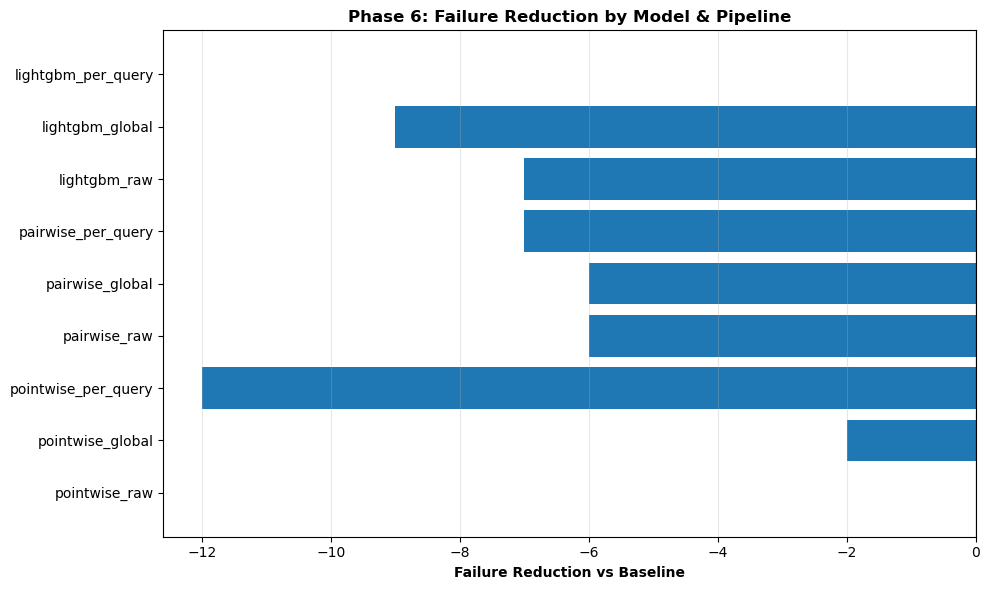

Saved: failure_reduction_plot.png


In [61]:
print("\n"+"="*80)
print("VISUALIZING FAILURE REDUCTION")
print("="*80)

fig, ax=plt.subplots(figsize=(10, 6))
red_df['config']=red_df['model'] + '_' + red_df['pipeline']
ax.barh(red_df['config'], red_df['delta'])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Failure Reduction vs Baseline', fontweight='bold')
ax.set_title('Phase 6: Failure Reduction by Model & Pipeline', fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(PHASE6_OUTPUT / 'failure_reduction_plot.png', dpi=150)
plt.show()
print("Saved: failure_reduction_plot.png")

This plot shows how each **model + pipeline** changed the number of **avoidable Failure@5 queries** compared to the Phase 5 baseline. The x-axis is **delta (baseline_total − current_total)**, so:

- Values **> 0** would mean fewer failures than baseline (good).
- Values **< 0** mean more failures than baseline (worse).
- Values **= 0** mean no change from baseline.


Almost all visible bars are on the **negative side**, which means most Phase 6 configurations produced **more avoidable failures** than the Phase 5 baseline. In other words, switching to pairwise ranking or LightGBM did not automatically reduce the number of "complete failures" at top-5, even if they improved ranking quality metrics like NDCG.

Some configurations are only slightly worse than baseline (bars close to zero), while others are clearly worse (more negative bars).


There are 9 total configurations (3 models × 3 pipelines). The reason only 7 bars appear is because **two configurations have delta = 0**.


The plot suggests that **Failure@5 is hard to reduce** using model changes alone. Even stronger ranking models can improve average ranking quality, but still may not reduce the number of queries where the top-5 contains zero relevant items. This supports the idea that some failures may be driven by weak feature signal or query difficulty rather than only the ranking algorithm.
